# Steam Top 1495 Games Dataset – CS433 Final Project

## Section 1: Data Loading and Overview
**Person 1**

This notebook covers the first stage of our data analysis pipeline: loading the dataset, inspecting its structure, and summarizing what we are working with before any cleaning or modeling begins.

### Importing libraries

In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

colors = sns.color_palette('hls')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)


### Loading and first look at the data

In [104]:
stream_games_path = 'data/steam_top_games_2026.csv'

steam_games = pd.read_csv(stream_games_path)

print(f'Dataset loaded successfully')
print(f'Shape: {steam_games.shape[0]} rows x {steam_games.shape[1]} columns')

steam_games.head()

Dataset loaded successfully
Shape: 1495 rows x 29 columns


,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,categories,tags,platforms_win,platforms_mac,platforms_linux,metacritic_score,recommendations,positive_reviews,negative_reviews,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,"Single-player, Multi-player, Co-op, Online Co-op, Shared...","RPG, Open World, Survival, Co-op, Online Co-Op, Local Co...",True,False,False,NaN,23986,20738,7717,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72,No remarkable journey is achieved without great effort. ...,https://shared.akamai.steamstatic.com/store_item_assets/...
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy","Single-player, Steam Trading Cards, Family Sharing","RPG, Strategy, Turn-Based, Classic, Horror, Post-apocaly...",True,True,True,NaN,909,1616,411,"200,000 .. 500,000",301,0,328,61,17,2,0,"November 2008. NATO intelligence services report that, f...",https://shared.akamai.steamstatic.com/store_item_assets/...
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie","Single-player, Steam Achievements, Steam Trading Cards, ...","Indie, Adventure, Visual Novel",True,True,False,NaN,0,79,35,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32,"Accompanied by beautiful piano music, you begin to exper...",https://shared.akamai.steamstatic.com/store_item_assets/...
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation","Single-player, Family Sharing","Simulation, Casual, RPG, Indie, Word Game, Idler",True,False,False,NaN,1169,769,509,"200,000 .. 500,000",5786,0,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，并且有大量玩家自制m...,https://shared.akamai.steamstatic.com/store_item_assets/...
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., Frozen Dist...","Casual, Indie, Simulation","Single-player, Steam Achievements, Steam Cloud, Family S...","Simulation, Casual, Indie, Trains, First-Person, Singlep...",True,False,False,68.0,1948,2154,466,"200,000 .. 500,000",448,0,201,16,0,1,73,"Welcome to an old, ruined train station. A place that wi...",https://shared.akamai.steamstatic.com/store_item_assets/...


### Determining the column names and data types


In [105]:
print('Column names and data types:')
print(steam_games.dtypes.to_string())

Column names and data types:
app_id                    int64
name                        str
release_date                str
coming_soon                bool
price_usd               float64
is_free                    bool
discount_pct              int64
developer                   str
publisher                   str
genres                      str
categories                  str
tags                        str
platforms_win              bool
platforms_mac              bool
platforms_linux            bool
metacritic_score        float64
recommendations           int64
positive_reviews          int64
negative_reviews          int64
estimated_owners            str
avg_playtime_forever      int64
avg_playtime_2weeks       int64
median_playtime           int64
peak_ccu                  int64
required_age              int64
dlc_count                 int64
achievements              int64
short_description           str
header_image                str


**Observations:**
- `release_date` is a string like `'May 17, 2022'` and needs to be parsed to datetime before we can extract the release year.
- `estimated_owners` stores ownership ranges like `'1,000,000 .. 2,000,000'` as a string. We will parse this into a numeric midpoint in the cleaning section.
- `price_usd`, `positive_reviews`, `negative_reviews`, and `recommendations` are numeric and ready to use.
- `is_free`, `platforms_win`, `platforms_mac`, `platforms_linux`, and `coming_soon` are boolean columns.

### Checking for missing values

In [106]:
null_count = steam_games.isnull().sum()
null_pct = (null_count / len(steam_games) * 100).round(2)

null_summary = pd.DataFrame({
    'Missing Count': null_count,
    'Missing %': null_pct,
})

null_summary = null_summary[null_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print('Columns with missing values:\n')
print(null_summary.to_string())

Columns with missing values:

                   Missing Count  Missing %
metacritic_score             955      63.88
publisher                     12       0.80
categories                     9       0.60
developer                      8       0.54
genres                         8       0.54
release_date                   7       0.47
tags                           6       0.40
estimated_owners               5       0.33
short_description              2       0.13
header_image                   1       0.07


**Observations:**
- `metacritic_score` is missing for 64% of games. Not all games get a Metacritic review, so this is expected. We are dropping this column entirely.
- `developer`, `publisher`, `genres`, `categories`, and `tags` each have fewer than 12 missing values. Easy to fill.
- Everything else is complete with no nulls.

### Displaying Summary Statistics

In [107]:
steam_games.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
app_id,1495.0,778052.84,673142.99,20.0,292770.0,544730.00,1148140.00,3358510.00
price_usd,1495.0,12.09,13.97,0.0,0.0,8.99,19.99,149.99
discount_pct,1495.0,9.41,24.57,0.0,0.0,0.00,0.00,94.00
metacritic_score,540.0,76.86,9.46,24.0,72.0,78.00,83.00,96.00
recommendations,1495.0,20141.01,142027.16,0.0,402.5,3419.00,11366.50,5037443.00
positive_reviews,1495.0,24220.18,206591.76,0.0,1637.5,4463.00,12735.50,7642084.00
negative_reviews,1495.0,3664.93,31807.03,0.0,317.5,739.00,2013.50,1173003.00
avg_playtime_forever,1495.0,1299.60,3316.74,0.0,205.0,415.00,1139.50,58347.00
avg_playtime_2weeks,1495.0,79.34,300.50,0.0,0.0,0.00,0.00,4204.00
median_playtime,1495.0,492.21,1656.02,0.0,92.5,213.00,426.50,33638.00


### Dataset Summary

The Steam Top 1495 Games Dataset has 1,488 rows and 29 columns after removing the 7 games with unparseable release dates. Each row is one game and covers pricing, reviews, playtime, genres, platform support, developer info, and ownership estimates. Release years range from 1999 to 2026, though the vast majority of titles are from 2005 onwards. 376 games are free to play and 1,112 are paid.

A few columns need work before analysis: `release_date` is stored as a string, `estimated_owners` is a range string that needs to be parsed into a number, and `metacritic_score` is missing for 64% of games so we will drop it entirely.

## Section 2: Exploratory Data Analysis (EDA)
**Person 2**

This section explores the dataset visually and statistically. The goal is to understand distributions, spot patterns, and identify relationships between key variables before any modeling begins.

In [108]:
# Calculate review score (positive review ratio)
steam_games['total_reviews'] = steam_games['positive_reviews'] + steam_games['negative_reviews']

steam_games['review_score'] = (steam_games['positive_reviews']/steam_games['total_reviews']).round(4)

# Parse release year
steam_games['release_year'] = pd.to_datetime(steam_games['release_date'], errors='coerce').dt.year

print('Data loaded. Shape:', steam_games.shape)

Data loaded. Shape: (1495, 32)


### Price Distribution

We look at how game prices are distributed across the dataset, excluding free games to focus on paid titles.

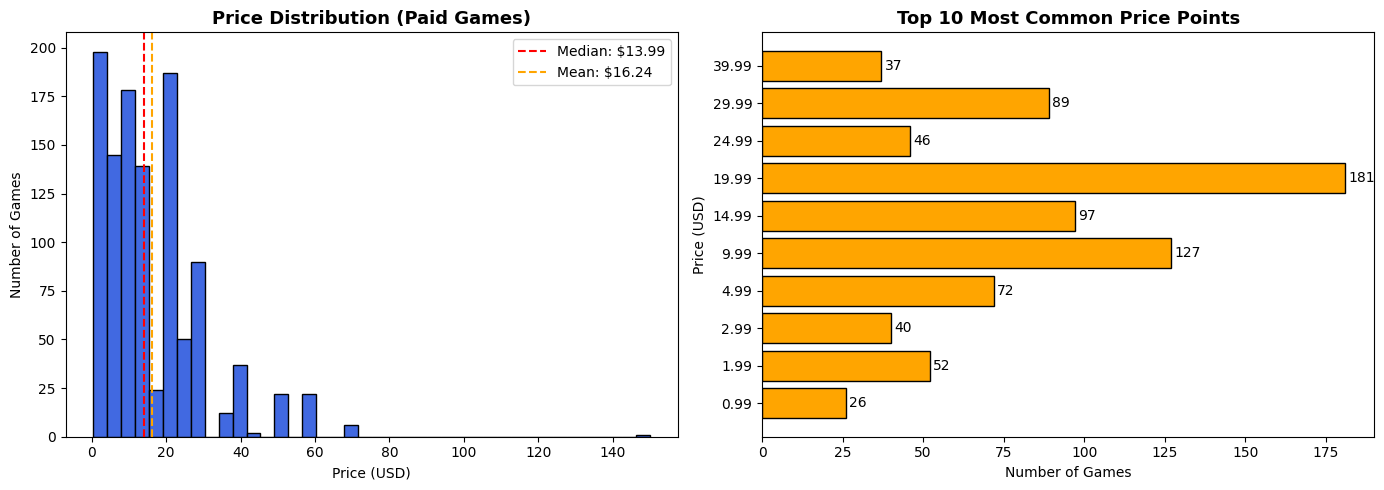

Paid game price stats:
count    1113.00
mean       16.24
std        13.95
min         0.49
25%         4.99
50%        13.99
75%        19.99
max       149.99


In [109]:
paid = steam_games[steam_games['price_usd'] > 0]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax[0].hist(
    paid['price_usd'],
    bins=40,
    color='royalblue',
    edgecolor='black'
)
ax[0].set_title('Price Distribution (Paid Games)', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Price (USD)')
ax[0].set_ylabel('Number of Games')
ax[0].axvline(
    paid['price_usd'].median(),
    color='red',
    linestyle='--',
    label=f'Median: ${paid["price_usd"].median()}'
)
ax[0].axvline(
    paid['price_usd'].mean(),
    color='orange',
    linestyle='--',
    label=f'Mean: ${paid["price_usd"].mean():.2f}'
)
ax[0].legend()

# Top price points
top_prices = paid['price_usd'].value_counts().head(10).sort_index()

ax[1].barh(top_prices.index.astype(str), top_prices.values, color='orange', edgecolor='black')
ax[1].set_title('Top 10 Most Common Price Points', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Number of Games')
ax[1].set_ylabel('Price (USD)')
for i, v in enumerate(top_prices.values):
    ax[1].text(v + 1, i,str(v), va='center')

plt.tight_layout()
plt.show()

print(f'Paid game price stats:')
print(paid['price_usd'].describe().round(2).to_string())

**Observations:**
- Prices cluster hard at a few common points. The top 5 most common prices are \\$19.99 (181 games), \\$9.99 (127), \\$14.99 (97), \\$29.99 (89), and \\$4.99 (72). Developers are clearly pricing to psychological anchors.
- The distribution is right-skewed. The median is \\$13.49 but the mean is \\$16.22, pulled up by a small number of premium titles going up to $149.99.
- This clustering is going to be a problem for linear regression since the model assumes a continuous relationship between features and price.

### Review Score Distribution

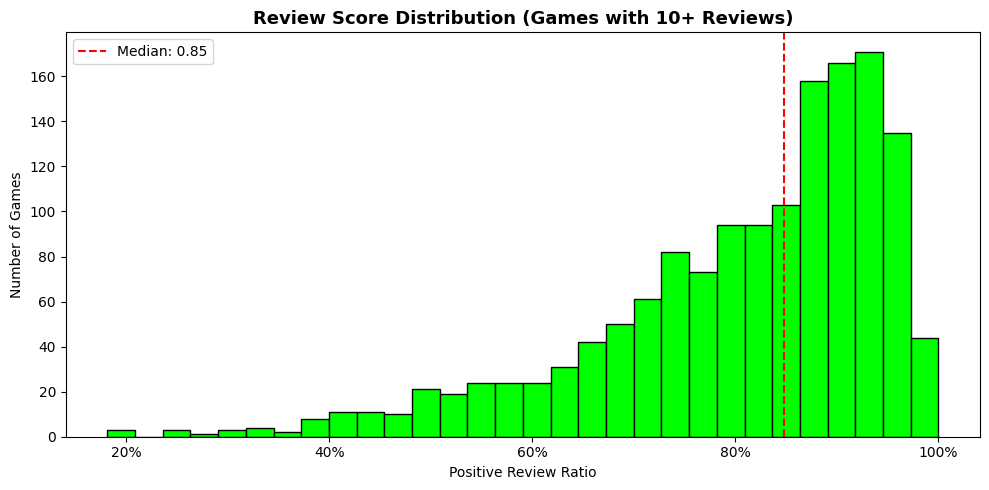

Median review score: 0.85
Mean review score: 0.81


In [110]:
review_df = steam_games[steam_games['total_reviews'] >= 10].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    review_df['review_score'],
    bins=30,
    color='lime',
    edgecolor='black'
)
ax.set_title('Review Score Distribution (Games with 10+ Reviews)', fontsize=13, fontweight='bold')
ax.set_xlabel('Positive Review Ratio')
ax.set_ylabel('Number of Games')
ax.axvline(
    review_df['review_score'].median(),
    color='red',
    linestyle='--',
    label=f'Median: {review_df["review_score"].median():.2f}'
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median review score: {review_df["review_score"].median():.2f}')
print(f'Mean review score: {review_df["review_score"].mean():.2f}')

**Observations:**
- The distribution is left-skewed. Most games in the top 1,495 have a positive review ratio above 75%, which makes sense since this is already a curated set of top-performing titles.
- The median review score is 84.8% and the mean is 80.6%. Games with very low review scores are clear outliers in this dataset.

### Review Score vs. Price

We explore whether higher-rated games tend to cost more

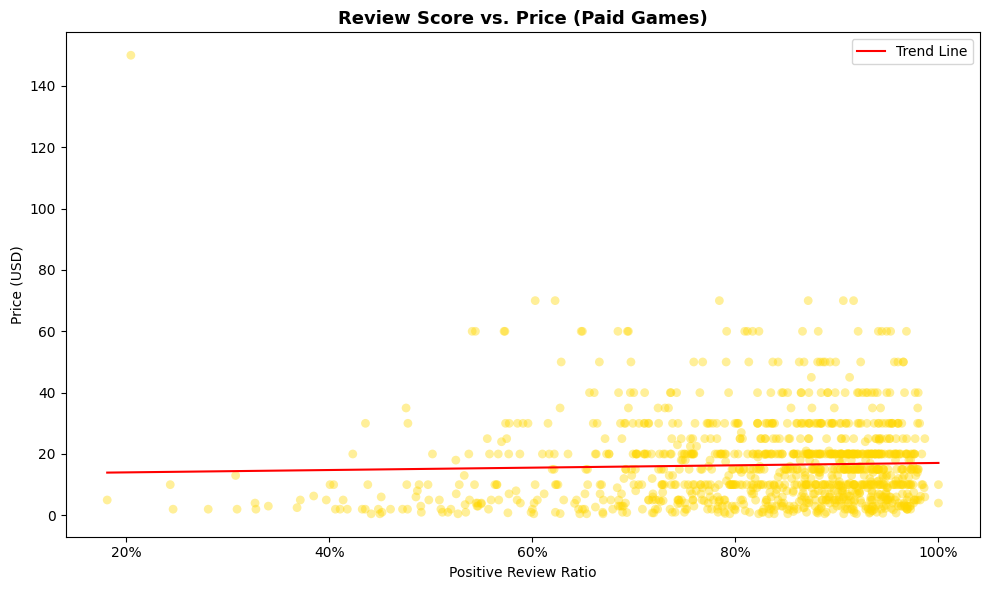

Pearson correlation (review score vs price): 0.0383


In [111]:
plot_df = review_df[review_df['price_usd'] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    plot_df['review_score'],
    plot_df['price_usd'],
    alpha=0.4,
    color='gold',
    edgecolor='none',
    s=40
)
ax.set_title('Review Score vs. Price (Paid Games)', fontsize=13, fontweight='bold')
ax.set_xlabel('Positive Review Ratio')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Trend line
z = np.polyfit(plot_df['review_score'], plot_df['price_usd'], 1)
p = np.poly1d(z)
x_line = np.linspace(
    plot_df['review_score'].min(),
    plot_df['review_score'].max(),
    100
)
ax.plot(x_line, p(x_line), color='red', linewidth=1.5, label='Trend Line')
ax.legend()
plt.tight_layout()
plt.show()

corr = plot_df['review_score'].corr(plot_df['price_usd'])
print(f'Pearson correlation (review score vs price): {corr:.4f}')

**Observations:**
- The Pearson correlation between review score and price is only 0.05. Review score is basically useless as a standalone price predictor.
- This means our regression model is going to need multiple features. A high review score alone does not justify a higher price on Steam.

### Average Price by Genre

We compare average price across the top 10 genres to see which genre tends to cost more.

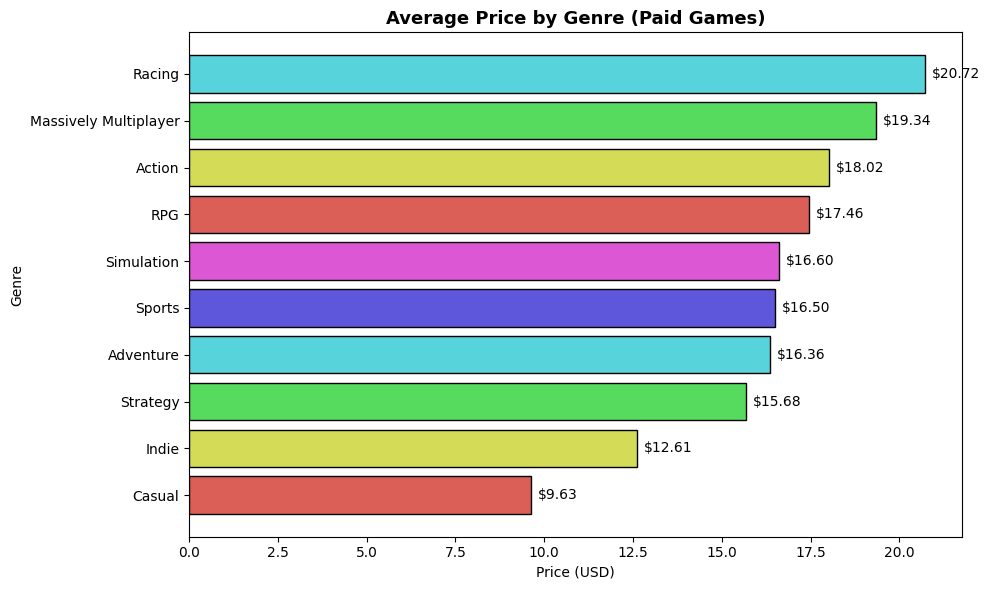

In [112]:
genre_price = []

exclude_genres = [
    'Audio Production', 'Video Production', 'Web Publishing', 'Free To Play',
    'Photo Editing', 'Accounting', 'Animation & Modeling', 'Game Development',
    'Education', 'Software Training', 'Utilities', 'Early Access',
    'Design & Illustration', 'Nudity', 'Gore', 'Violent'
]

for _, row in steam_games[steam_games['price_usd'] > 0].iterrows():
    if pd.notna(row['genres']):
        for genre in row['genres'].split(', '):
            genre_price.append({'genre': genre, 'price_usd': row['price_usd']})

genre_price_df = pd.DataFrame(genre_price)

genre_price_df = genre_price_df[~genre_price_df['genre'].isin(exclude_genres)]
avg_price_genre = genre_price_df.groupby('genre')['price_usd'].mean().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(avg_price_genre.index[::-1], avg_price_genre.values[::-1], color=colors, edgecolor='black')
ax.set_title('Average Price by Genre (Paid Games)', fontsize=13, fontweight='bold')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Genre')
for bar, val in zip(bars, avg_price_genre.values[::-1]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2, f'${val:.2f}', va='center')
plt.tight_layout()
plt.show()


**Observations:**
- The genres column mixes actual game genres with Steam software categories like Audio Production, Video Production, and Early Access. We filtered those out before running this chart.
- Racing (\\$20.72) and Massively Multiplayer (\\$19.34) have the highest average prices. Action and RPG follow at around \\$18.
- Casual and Indie games are the cheapest, which lines up with how those games are typically positioned on Steam.
- Genre is going to be a useful categorical feature in the regression model.

### Correlation Heatmap

We plot a correlation heatmap across all features to identify relationships the are worth exploring in our regression model.

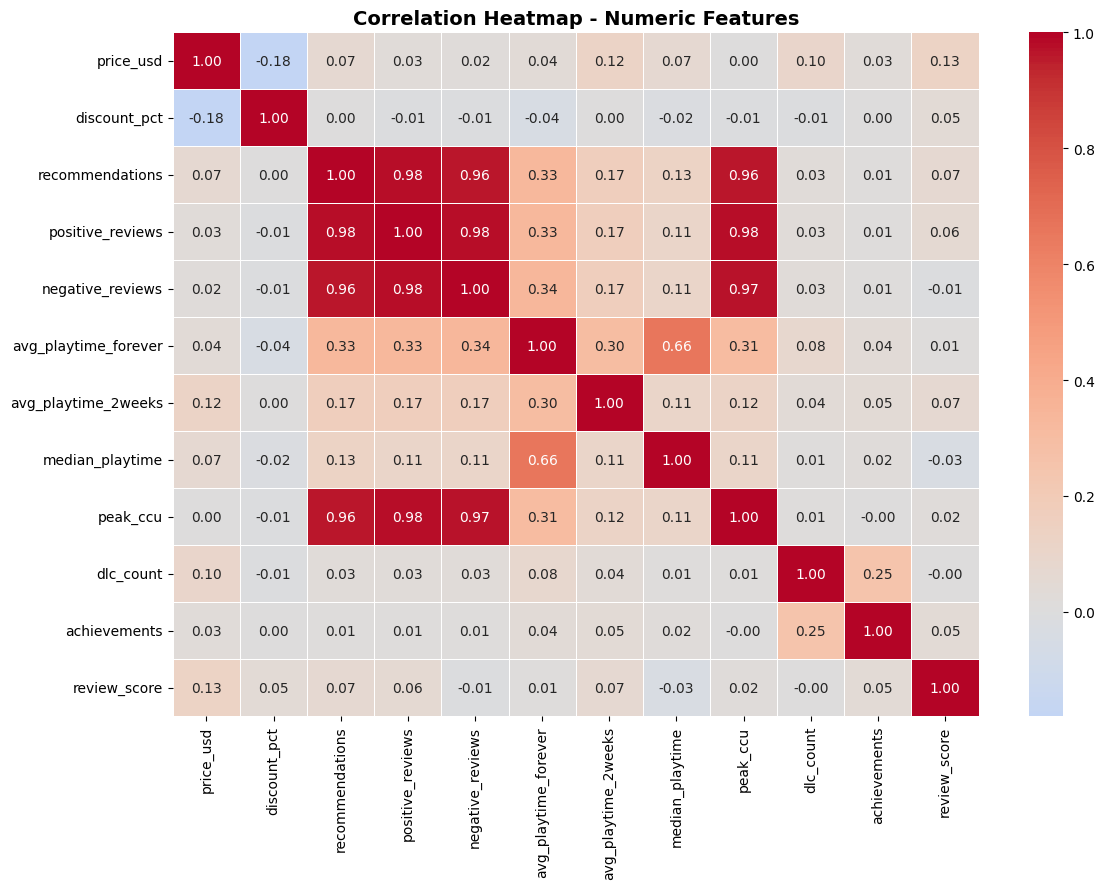

In [113]:
numeric_col = [
    'price_usd', 'discount_pct', 'recommendations', 'positive_reviews',
    'negative_reviews', 'avg_playtime_forever', 'avg_playtime_2weeks',
    'median_playtime', 'peak_ccu', 'dlc_count', 'achievements', 'review_score',
]

corr_matrix = steam_games[numeric_col].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=ax,
    linewidths=0.5,
    center=0
)
ax.set_title('Correlation Heatmap - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- `recommendations`, `positive_reviews`, `negative_reviews`, and `peak_ccu` are all correlated at 0.96-0.98 with each other. That is extreme multicollinearity. We only use `recommendations` in the model.
- `avg_playtime_forever` and `median_playtime` have a moderate correlation of 0.66, expected since both measure how long people play.
- No single numeric feature has a strong correlation with `price_usd`. The strongest are `review_score` (0.13) and `avg_playtime_2weeks` (0.12). Both are weak.
- `discount_pct` has a -0.18 correlation with price, meaning higher-priced games actually get smaller discounts, not larger ones.
- `dlc_count` and `achievements` correlate at 0.25 with each other, suggesting content-heavy games tend to have both.

### EDA Summary

- Prices cluster at psychological price points (\\$4.99, \\$9.99, \\$14.99, \\$19.99, \\$29.99) with a right-skewed distribution. Median is \\$13.49, mean is \\$16.22.
- Racing and Massively Multiplayer have the highest average prices after filtering out non-game Steam categories.
- Most top-performing games have positive review ratios above 75%. The median is 84.8%.
- Review score alone has a 0.05 correlation with price. It is not a useful standalone predictor.
- `recommendations`, `positive_reviews`, `negative_reviews`, and `peak_ccu` are all highly correlated (0.96-0.98). Only one goes into the model.
- No single numeric feature strongly predicts price. The model will need multiple features including genre.

## Section 3: Data Cleaning and Wrangling
**Person 3**

This section prepares the dataset for analysis and modeling. We handle missing values, fix data types, parse complex columns, resolve inconsistencies, and engineer new features that will be used in Sections 4 and 5.

### Null Value Audit

Before cleaning, we document exactly what is missing and decide how to handle each column

In [114]:
null_counts = steam_games.isnull().sum()
null_pct = (null_counts / len(steam_games) * 100).round(2)

null_summary = pd.DataFrame({
    'Missing Count': null_counts,
    'Missing %': null_pct,
})
null_summary = null_summary[null_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(null_summary[['Missing Count', 'Missing %']].to_string())

                   Missing Count  Missing %
release_year                1366      91.37
metacritic_score             955      63.88
publisher                     12       0.80
categories                     9       0.60
developer                      8       0.54
genres                         8       0.54
review_score                   8       0.54
release_date                   7       0.47
tags                           6       0.40
estimated_owners               5       0.33
short_description              2       0.13
header_image                   1       0.07


**Cleaning plan:**
- `metacritic_score`: Drop the column. 64% of values are missing and it will not be used in modeling.
- `developer`, `publisher`, `genres`, `categories`, `tags`: Fill nulls with `'Unknown'` to preserve rows.
- `estimated_owners`: Parse the string range into a numeric midpoint. Fill the 5 nulls with the median.
- `release_date`: Parse to datetime. Drop the 7 rows where parsing fails.
- `short_description`, `header_image`: Drop columns as it is not used in analysis or modeling.

### Drop Unused Columns

In [115]:
cols_to_drop = ['metacritic_score', 'short_description', 'header_image']
steam_games.drop(columns=cols_to_drop, inplace=True)

print(f'Dropped columns: {cols_to_drop}')
print(f'Shape after drop: {steam_games.shape}')

Dropped columns: ['metacritic_score', 'short_description', 'header_image']
Shape after drop: (1495, 29)


### Fill Missing String Columns

In [116]:
string_cols = ['developer', 'publisher', 'genres', 'categories', 'tags']
for col in string_cols:
    before = steam_games[col].isnull().sum()
    steam_games[col] = steam_games[col].fillna('Unknown')
    print(f'{col:<15} nulls before: {before} -> after: {steam_games[col].isnull().sum()}')

developer       nulls before: 8 -> after: 0
publisher       nulls before: 12 -> after: 0
genres          nulls before: 8 -> after: 0
categories      nulls before: 9 -> after: 0
tags            nulls before: 6 -> after: 0


### Parse release_date to Datetime

In [117]:
steam_games['release_date'] = pd.to_datetime(steam_games['release_date'], format='mixed', errors='coerce')

# Drop rows where date could not be parsed
failed_parse = steam_games['release_date'].isnull().sum()
steam_games.dropna(subset=['release_date'], inplace=True)

# Extract time features
steam_games['release_year'] = steam_games['release_date'].dt.year
steam_games['release_month'] = steam_games['release_date'].dt.month

print(f'Rows dropped due to date parsing errors: {failed_parse}')
print(f'Shape after date parsing: {steam_games.shape}')
print(f'Release year range: {steam_games['release_year'].min()} - {steam_games['release_year'].max()}')

Rows dropped due to date parsing errors: 7
Shape after date parsing: (1488, 30)
Release year range: 1999 - 2026


### Parse estimated_owners to Numeric

In [118]:
def parse_owners(val):
    if pd.isna(val):
        return np.nan
    parts = str(val).replace(',', '').split('..')
    if len(parts) == 2:
        low = float(parts[0].strip())
        high = float(parts[1].strip())
        return (low + high) / 2
    return np.nan

steam_games['estimated_owners_mid'] = steam_games['estimated_owners'].apply(parse_owners)

# Fill remaining nulls with median
median_owners = steam_games['estimated_owners_mid'].median()
steam_games['estimated_owners_mid'] = steam_games['estimated_owners_mid'].fillna(median_owners)

print(f'estimated_owners_mid sample:')
print(steam_games[['estimated_owners', 'estimated_owners_mid']].head().to_string())
print(f'Nulls remaining: {steam_games['estimated_owners_mid'].isnull().sum()}')

estimated_owners_mid sample:
         estimated_owners  estimated_owners_mid
0  1,000,000 .. 2,000,000             1500000.0
1      200,000 .. 500,000              350000.0
2  2,000,000 .. 5,000,000             3500000.0
3      200,000 .. 500,000              350000.0
4      200,000 .. 500,000              350000.0
Nulls remaining: 0


### Resolve Price vs. is_free Inconsistency

We found that about 376 games have a price_usd of 0, but only 249 are marked is_free = True

In [119]:
zero_price = steam_games[steam_games['price_usd'] == 0]
is_free_true = steam_games[steam_games['is_free'] == True]

print(f'Games with price_usd = 0: {len(zero_price)}')
print(f'Games with is_true = True: {len(is_free_true)}')
print(f'Overlap (both): {len(steam_games[(steam_games['price_usd'] == 0) & (steam_games['is_free'] == True)])}')
print(f'price=0 but is_free=False: {len(steam_games[(steam_games['price_usd'] == 0) & (steam_games['is_free'] == False)])}')
print(f'is_free=True but price > 0: {len(steam_games[(steam_games['price_usd'] > 0) & (steam_games['is_free'] == False)])}')

# Fix: if price is 0, treat as free regardless of is_free flag
steam_games['is_free_clean'] = steam_games['price_usd'] == 0
print(f'\nis_free_clean distribution:')
print(steam_games['is_free_clean'].value_counts().to_string())


Games with price_usd = 0: 376
Games with is_true = True: 249
Overlap (both): 248
price=0 but is_free=False: 128
is_free=True but price > 0: 1111

is_free_clean distribution:
is_free_clean
False    1112
True      376


**Observations:**
- 128 games have `price_usd == 0` but `is_free == False`. These are likely games that went free-to-play after launch but never had their flag updated.
- We created `is_free_clean` using `price_usd == 0` as the source of truth since the price column is more reliable than the flag.

### Create primary_genre Feature

In [120]:
exclude_genres = [
    'Audio Production', 'Video Production', 'Web Publishing',
    'Free To Play', 'Photo Editing', 'Accounting', 'Animation & Modeling',
    'Game Development', 'Education', 'Software Training', 'Utilities',
    'Early Access', 'Design & Illustration', 'Nudity', 'Gore', 'Violent',
]

def get_primary_genre(genre_str):
    if pd.isna(genre_str) or genre_str == 'Unknown':
        return 'Unknown'
    genres = [g.strip() for g in genre_str.split(', ')]
    for g in genres:
        if g not in exclude_genres:
            return g
    return 'Other'

steam_games['primary_genre'] = steam_games['genres'].apply(get_primary_genre)

print('Primary genre distribution (top 10):')
print(steam_games['primary_genre'].head(10).to_string())

Primary genre distribution (top 10):
0           RPG
1           RPG
2     Adventure
3        Casual
4        Casual
5    Simulation
6        Action
7           RPG
8     Adventure
9        Action


### Create review_score Feature

In [121]:
steam_games['total_reviews'] = steam_games['positive_reviews'] + steam_games['negative_reviews']
steam_games['review_score'] = np.where(
    steam_games['total_reviews'] > 0,
    steam_games['positive_reviews'] / steam_games['total_reviews'],
    np.nan
)
steam_games['review_score'] = steam_games['review_score'].fillna(steam_games['review_score'].median())

print(f'review_score stats:')
print(steam_games['review_score'].describe().round(4).to_string())

review_score stats:
count    1488.0000
mean        0.8048
std         0.1467
min         0.0000
25%         0.7312
50%         0.8472
75%         0.9151
max         1.0000


### Final Null Check

In [122]:
remaining_nulls = steam_games.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

if len(remaining_nulls) == 0:
    print('No remaining nulls in any column used for analysis or modeling.')
else:
    print('Remaining nulls:')
    print(remaining_nulls.to_string())

Remaining nulls:
estimated_owners    5


## Section 4: Aggregation and Insights
**Person 4**

This section aggregates the cleaned dataset to find meaningful patterns. We answer four key questions: which games are most recommended, how review scores differ by genre, how prices differ by genre, and how the Steam library has grown over time.

In [123]:
dataset_path = 'data/steam_top_games_2026_cleaned.csv'
steam_games = pd.read_csv(dataset_path)

print(f'Cleaned dataset loaded. Shape: {steam_games.shape}')


Cleaned dataset loaded. Shape: (1488, 39)


### Top 10 Most Recommended Games

Top 10 Most Recommended Games:
                     name  recommendations primary_genre  price_usd
1        Counter-Strike 2          5037443        Action       0.00
2                    Rust          1126145        Action      39.99
3         Baldur's Gate 3           734964     Adventure      59.99
4            Phasmophobia           666253        Action      19.99
5        Dead by Daylight           652542        Action      19.99
6   ARK: Survival Evolved           575975        Action       9.89
7                 Valheim           450092        Action      19.99
8                    DayZ           379100        Action      49.99
9             Dying Light           369315        Action      24.99
10  Monster Hunter: World           313996        Action      29.99


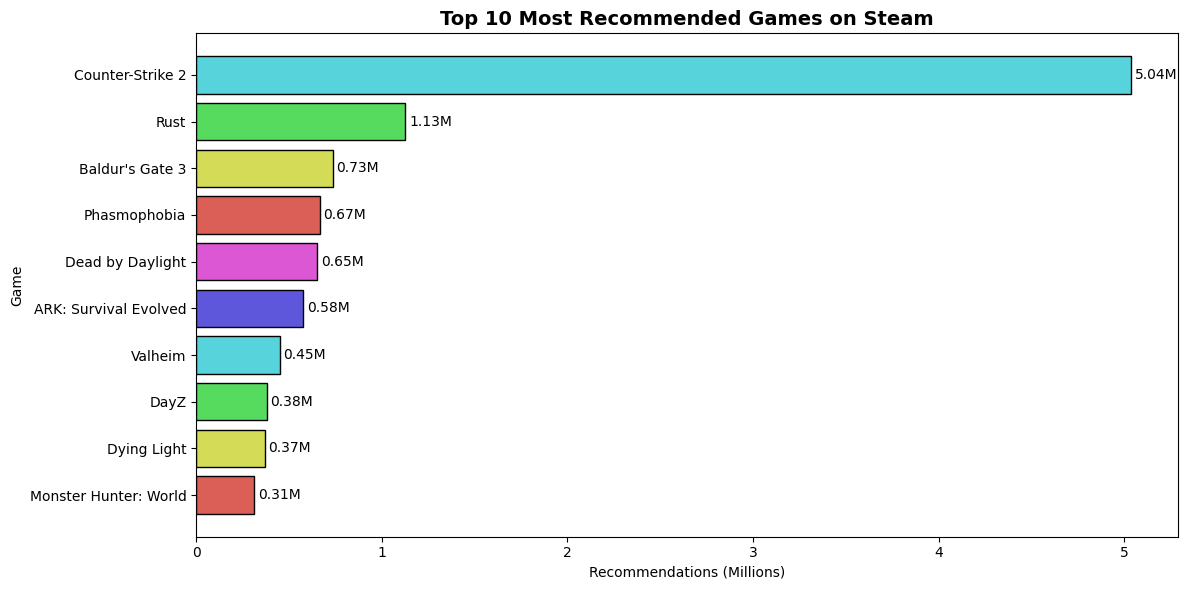

In [124]:
top_recommended = steam_games.nlargest(10, 'recommendations')[['name', 'recommendations', 'primary_genre', 'price_usd']]
top_recommended = top_recommended.reset_index(drop=True)
top_recommended.index += 1

print('Top 10 Most Recommended Games:')
print(top_recommended.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top_recommended['name'][::-1],
    top_recommended['recommendations'][::-1] / 1_000_000,
    color=colors, edgecolor='black'
)
ax.set_title('Top 10 Most Recommended Games on Steam', fontsize=14, fontweight='bold')
ax.set_xlabel('Recommendations (Millions)')
ax.set_ylabel('Game')
for bar, val in zip(bars, top_recommended['recommendations'][::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val/1_000_000:.2f}M', va='center')
plt.tight_layout()
plt.show()

**Observations:**
- Counter-Strike 2 has 5.04M recommendations, nearly 4.5x the second-place game (Rust at 1.13M). The gap is massive.
- 8 out of the top 10 are Action genre games. The top 10 is basically a survival/multiplayer games list: CS2, Rust, Phasmophobia, DayZ, Valheim, ARK, Dying Light, and Monster Hunter.
- Baldur's Gate 3 at $59.99 is the most expensive game in the top 10 with 735K recommendations, showing that premium pricing does not stop players from recommending a game they love.

### Average Review Score by Genre

Average Review Score by Genre (min 10 games):
                       avg_review_score  game_count
primary_genre                                      
Adventure                         0.829         265
Indie                             0.827         104
Strategy                          0.826          35
Casual                            0.815         114
Racing                            0.809          27
Action                            0.800         782
RPG                               0.790          53
Simulation                        0.766          52
Other                             0.748          25
Massively Multiplayer             0.679          15


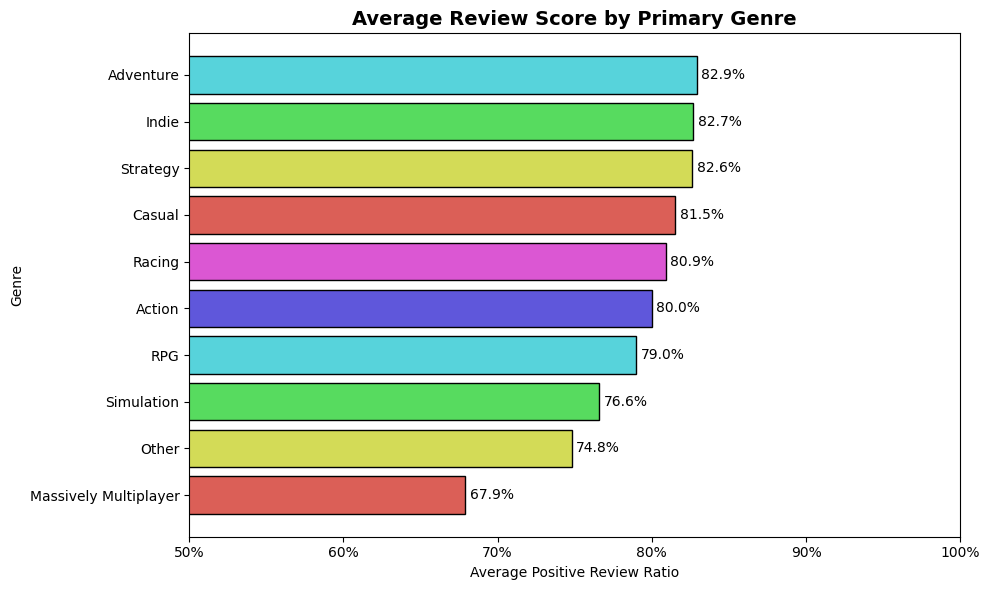

In [125]:
review_by_genre = (
    steam_games[steam_games['primary_genre'] != 'Unknown']
    .groupby('primary_genre')['review_score']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_review_score', 'count': 'game_count'})
    .query('game_count >= 10')
    .sort_values('avg_review_score', ascending=False)
    .round(3)
)

print('Average Review Score by Genre (min 10 games):')
print(review_by_genre.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    review_by_genre.index[::-1],
    review_by_genre['avg_review_score'][::-1],
    color=colors, edgecolor='black'
)
ax.set_title('Average Review Score by Primary Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Positive Review Ratio')
ax.set_ylabel('Genre')
ax.set_xlim(0.5, 1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
for bar, val in zip(bars, review_by_genre['avg_review_score'][::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2, f'{val:.1%}', va='center')
plt.tight_layout()
plt.show()

**Observations:**
- Adventure (82.95%) and Indie (82.68%) have the highest average review scores, followed closely by Strategy (82.63%).
- Massively Multiplayer games have the lowest average review score at 67.91%, likely because this genre attracts large player bases with higher expectations and more vocal frustrated players.
- The spread goes from 67.9% to 83%, which is not huge given this is already a dataset of top-performing games.

### Average Price by Genre (Paid Games)

We compare average prices across genres to understand how genre relates to pricing strategy.

Average and Median Price by Genre (min 5 paid games):
               avg_price  median_price  game_count
primary_genre                                     
Racing             25.28         24.99          17
Simulation         20.45         18.99          38
RPG                18.24         14.99          44
Action             18.02         14.99         600
Indie              15.87         14.99          81
Strategy           12.56          9.99          29
Adventure          12.27          9.99         216
Casual              9.18          6.49          72


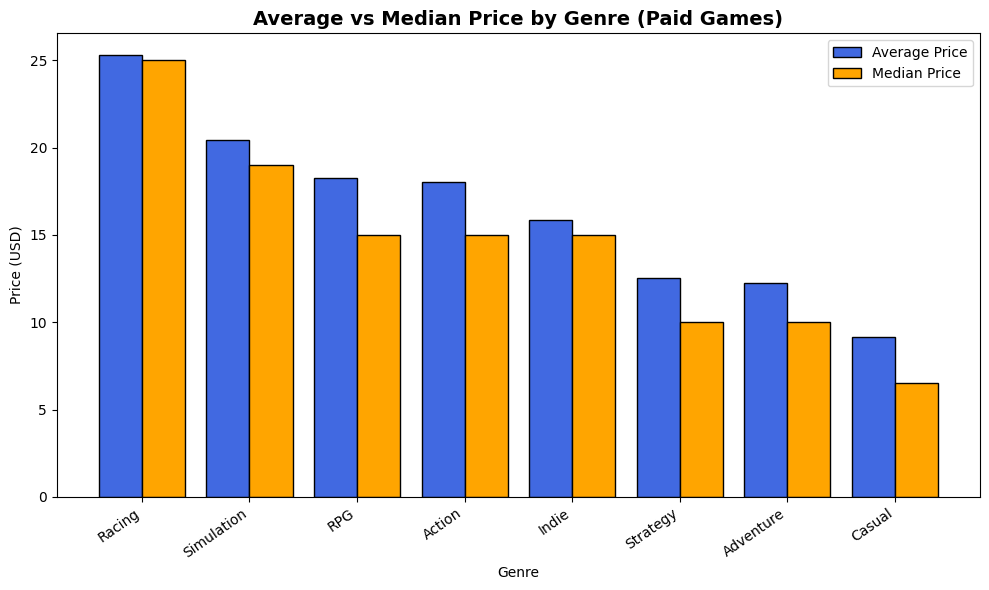

In [126]:
price_by_genre = (
    steam_games[(steam_games['price_usd'] > 0) &
                (steam_games['primary_genre'] != 'Unknown') &
                (steam_games['primary_genre'] != 'Other')]
    .groupby('primary_genre')['price_usd']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'avg_price', 'median': 'median_price', 'count': 'game_count'})
    .query('game_count >= 5')
    .sort_values('avg_price', ascending=False)
    .round(2)
)

print('Average and Median Price by Genre (min 5 paid games):')
print(price_by_genre.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(price_by_genre))
width = 0.4
bars1 = ax.bar([i - width/2 for i in x], price_by_genre['avg_price'], width=width,
               label='Average Price', color='royalblue', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], price_by_genre['median_price'], width=width,
               label='Median Price', color='orange', edgecolor='black')
ax.set_title('Average vs Median Price by Genre (Paid Games)', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Price (USD)')
ax.set_xticks(list(x))
ax.set_xticklabels(price_by_genre.index, rotation=35, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**
- Racing leads at $25.28 average with a $24.99 median, so prices in that genre are pretty consistent with few outliers.
- Simulation ($20.45) and RPG ($18.24) follow. Both have a bigger gap between average and median, meaning a few premium titles are pulling the average up.
- Action has 600 games in this dataset, by far the most, but averages $18.02 with a $14.99 median. That $14.99 is essentially Steam's default mid-tier price point.
- Casual is the cheapest at $9.18 average and $6.49 median.
- For every genre, the average is higher than the median, which confirms the right-skewed price distribution we saw in Section 2.

### Games Released Per Year

We track how many top-performing games were released each year to understand Steam's growth over time.

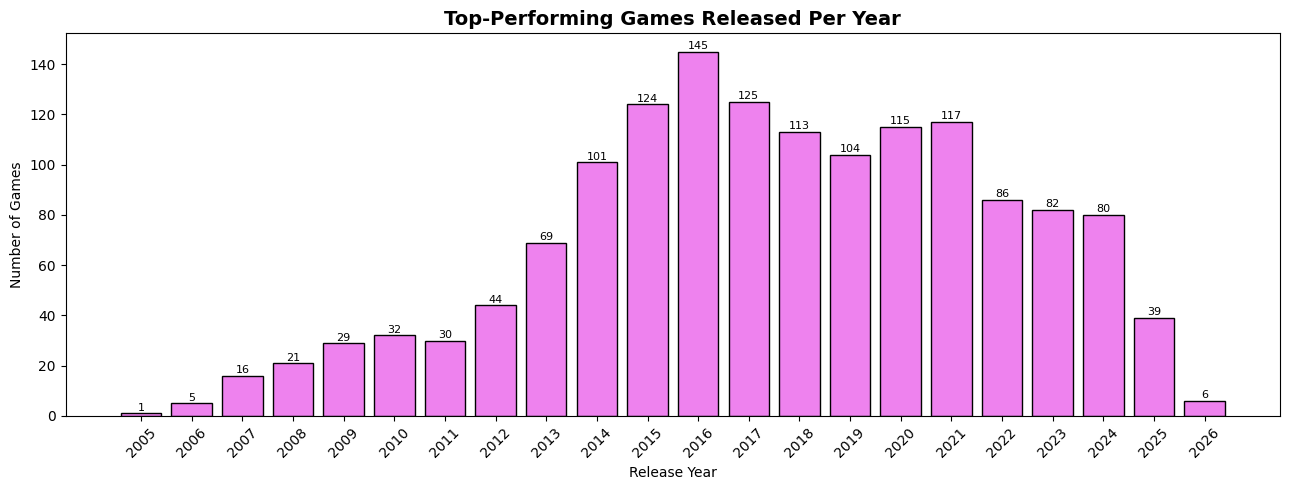

Peak year: 2016 with 145 games

Games released 2020 onwards:
release_year
2020    115
2021    117
2022     86
2023     82
2024     80
2025     39
2026      6


In [127]:
year_counts = steam_games['release_year'].value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 2005]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(year_counts.index, year_counts.values, color='violet', edgecolor='black')
ax.set_title('Top-Performing Games Released Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Games')
ax.set_xticks(year_counts.index)
ax.set_xticklabels(year_counts.index, rotation=45)
for i, (yr, cnt) in enumerate(year_counts.items()):
    ax.text(yr, cnt + 1, str(cnt), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

peak_year = year_counts.idxmax()
print(f'Peak year: {peak_year} with {year_counts[peak_year]} games')
print(f'\nGames released 2020 onwards:')
print(year_counts[year_counts.index >= 2020].to_string())

**Observations:**
- Top-game releases peaked in 2016 with 145 games, right around when Steam transitioned from Greenlight to Steam Direct, which made it easier for developers to publish.
- The count drops after 2016 but that does not mean fewer games were released. It just means newer games have not had enough time to accumulate the reviews and recommendations needed to rank in the top 1,495.
- Only 6 games from 2026 appear here since the dataset was collected in April 2026.

### Aggregation Summary

- Counter-Strike 2 is the most recommended game with 5.04M recommendations, nearly 4.5x its nearest competitor.
- Adventure and Indie genres have the highest average review scores (83%). Massively Multiplayer is the lowest at 67.9%.
- Racing games have the highest average price at $25.28. Casual games are the most affordable at $9.18.
- Top-game releases peaked in 2016 and have declined since. This reflects how long it takes for newer games to accumulate reviews, not a drop in Steam's output.
- Action games lead mean estimated ownership at 2.21M, followed by Strategy (1.58M) and Simulation (1.29M).

## Section 5: Linear Regression Model
**Person 5**

This section builds a linear regression model to predict a game's price based on its features. We use the cleaned dataset from Section 3, select features based on the EDA findings from Section 2, train and evaluate the model, and interpret the results.

In [128]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

dataset_path = 'data/steam_top_games_2026_cleaned.csv'
steam_games = pd.read_csv(dataset_path)

print(f'Cleaned dataset loaded. Shape: {steam_games.shape}')

Cleaned dataset loaded. Shape: (1488, 39)


### Filter to Paid Games Only

In [129]:
paid = steam_games[steam_games['price_usd'] > 0].copy()
print(f'Paid fames available for modeling: {len(paid)}')
print(f'Price range: ${paid["price_usd"].min()} - {paid["price_usd"].max()}')
print(f'Median price: ${paid["price_usd"].median()}')

Paid fames available for modeling: 1112
Price range: $0.49 - 149.99
Median price: $13.49


### Feature Selection

Based on the correlation heatmap in Section 2, all numeric features have weak individual correlations with `price_usd`. No single feature is a strong predictor. We select the most meaningful available features while avoiding multicollinear pairs.

Features selected:
- `review_score`: Highest numeric correlation with price (0.13). Included as a quality signal.
- `avg_playtime_2weeks`: Proxy for recent player engagement (0.12).
- `dlc_count`: Content richness indicator (0.10).
- `recommendations`: Proxy for overall popularity (0.07).
- `avg_playtime_forever`: Proxy for game depth (0.04).
- `release_year`: Not in the heatmap but added as a domain-knowledge feature. Newer games tend to be priced higher due to inflation and rising development costs.
- `primary_genre`: Categorical feature encoding genre pricing patterns observed in Section 4.

We exclude `positive_reviews`, `negative_reviews`, and `peak_ccu` due to extreme multicollinearity with `recommendations` (0.96-0.98). The low correlations across all features tell us upfront that the model's R2 will be limited, which we address in later

In [130]:
valid_genres = paid['primary_genre'].value_counts()
valid_genres = valid_genres[valid_genres >= 10].index.tolist()
paid = paid[paid['primary_genre'].isin(valid_genres)].copy()

genre_dummies = pd.get_dummies(paid['primary_genre'], prefix='genre', drop_first=True)

feature_cols = ['release_year', 'recommendations', 'avg_playtime_forever', 'avg_playtime_2weeks', 'dlc_count', 'review_score']
X = pd.concat([paid[feature_cols].reset_index(drop=True), genre_dummies.reset_index(drop=True)], axis=1)
y = paid['price_usd'].reset_index(drop=True)

print(f'Feature matrix shape: {X.shape}')
print(f'Features used: {list(X.columns)}')

Feature matrix shape: (1097, 13)
Features used: ['release_year', 'recommendations', 'avg_playtime_forever', 'avg_playtime_2weeks', 'dlc_count', 'review_score', 'genre_Adventure', 'genre_Casual', 'genre_Indie', 'genre_RPG', 'genre_Racing', 'genre_Simulation', 'genre_Strategy']


### Train/Test Split

We use an 80/20 train/test split with a fixed random state for reproducibility.

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set size : {len(X_train)}')
print(f'Test set size     : {len(X_test)}')

Training set size : 877
Test set size     : 220


### Train the Model

In [132]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model trained successfully.')
print(f'Intercept: {model.intercept_:.4f}')

Model trained successfully.
Intercept: 15.8832


### Model Evaluation

In [133]:
y_pred = model.predict(X_test_scaled)
# Clip negative predictions since prices cannot be negative
y_pred = np.clip(y_pred, 0, None)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# Cross-validated R2
cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='r2')

print('Model Evaluation Metrics:')
print(f'  MAE  (Mean Absolute Error): ${mae:.2f}')
print(f'  RMSE (Root Mean Squared Error): ${rmse:.2f}')
print(f'  R2   (Coefficient of Determ.): {r2:.4f}')
print(f'  5-Fold CV R2 Mean: {cv_scores.mean():.4f}')
print(f'  5-Fold CV R2 Std: {cv_scores.std():.4f}')

Model Evaluation Metrics:
  MAE  (Mean Absolute Error): $9.70
  RMSE (Root Mean Squared Error): $13.37
  R2   (Coefficient of Determ.): 0.1938
  5-Fold CV R2 Mean: -0.2056
  5-Fold CV R2 Std: 0.6842


### Actual vs. Predicted Price Plot

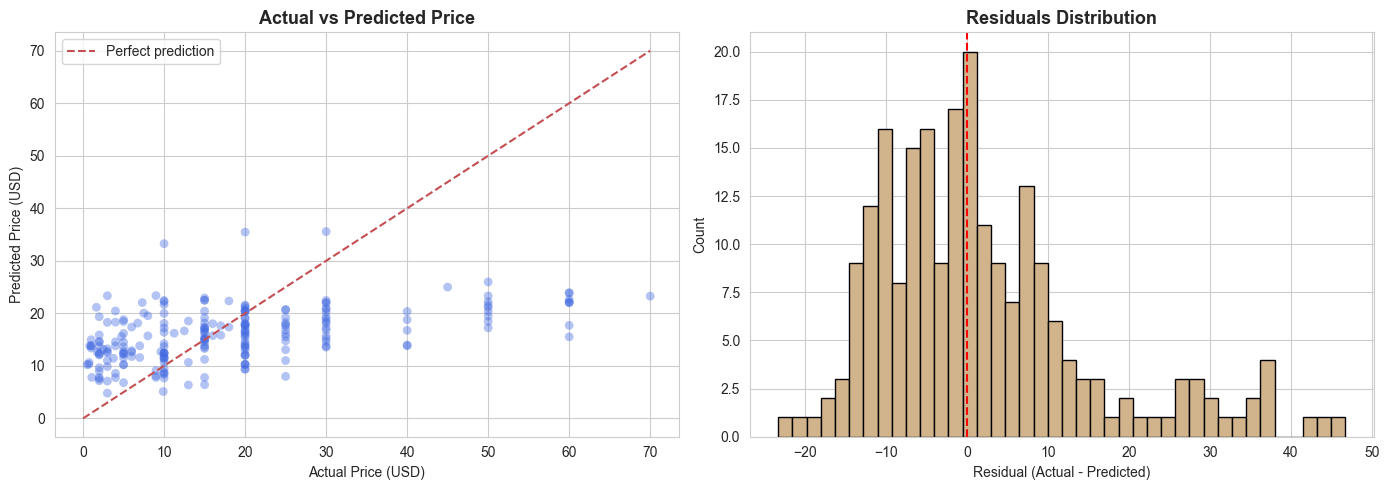

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred, alpha=0.4, color='royalblue', edgecolors='none', s=40)
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title('Actual vs Predicted Price', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].legend()

# Residuals distribution
residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='tan', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Observations:**
- The model consistently underpredicts high-priced games. Most points sit below the perfect prediction line once you get above \\$20.
- For games priced between \\$0 and \\$20, predictions are reasonable. Above \\$30 the model struggles.
- The vertical stacking of points at \\$10, \\$15, and \\$20 is the price clustering from Section 2 showing up directly in the predictions. The model cannot tell apart two games priced at the same psychological price point.
- The residuals are slightly right-skewed with a tail out to +45. The model's biggest errors are all underpredictions on premium games.
- Most residuals fall between -15 and +15, consistent with the $9.70 MAE.

### Feature Coefficients

We examin the which featurehas a largest impact on predicted price.

Feature Coefficients (sorted by absolute value):
             Feature  Coefficient
        release_year     3.616563
        genre_Casual    -1.964129
     genre_Adventure    -1.811631
     recommendations     1.406095
        genre_Racing     1.184699
           dlc_count     1.183829
 avg_playtime_2weeks     0.961750
        review_score     0.724747
avg_playtime_forever     0.617505
      genre_Strategy    -0.594985
         genre_Indie    -0.509663
           genre_RPG     0.391925
    genre_Simulation     0.334099


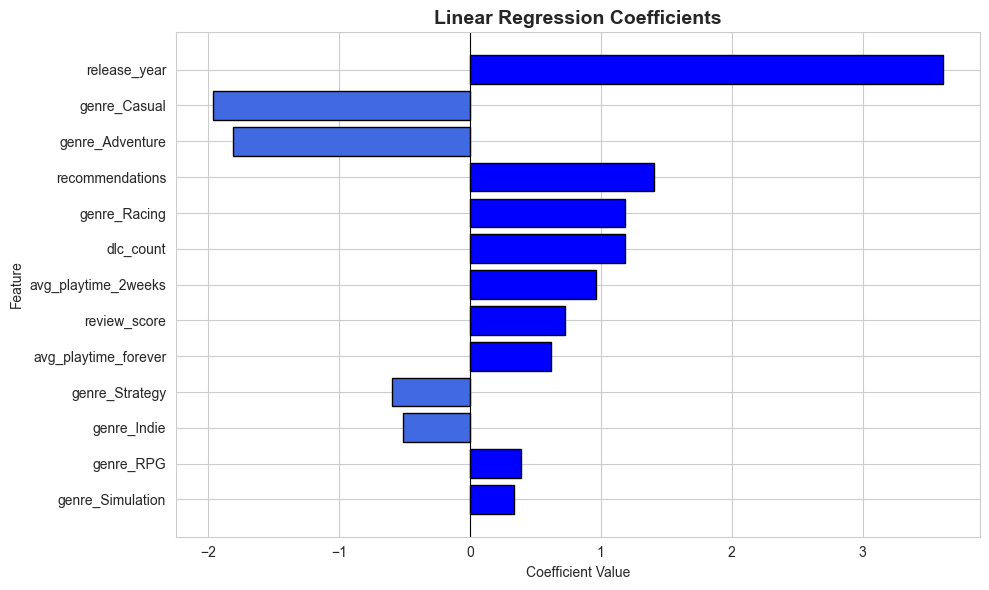

In [135]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature Coefficients (sorted by absolute value):')
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue' if c >= 0 else 'royalblue' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1], edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression Coefficients', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

**Observations:**
- `release_year` has the strongest coefficient at 3.62. Newer games cost more, which makes sense given inflation and rising development costs.
- `genre_Casual` (-1.96) and `genre_Adventure` (-1.81) are the strongest negative signals. Being in either of those genres pulls the predicted price down significantly relative to Action (the baseline genre).
- `recommendations` (1.41) and `dlc_count` (1.18) both push price up. More popular and more content-rich games tend to cost more.
- `genre_Racing` (1.18) is the strongest positive genre signal, matching what we saw in Section 4.
- `review_score` has a coefficient of 0.72. After controlling for everything else, quality does have a slight upward effect on price, even though its raw correlation with price was only 0.05.

### Model Limitations and Discussion

**Why the R2 is low (0.19):**

Steam pricing is set by developers based on production budget, publisher deals, and market positioning. None of that is in this dataset. The features we have just are not the things that determine price.

On top of that, prices cluster at fixed psychological price points (\\$4.99, \\$9.99, \\$14.99, \\$19.99, \\$29.99). Linear regression assumes a continuous relationship between features and the target, which breaks down when the target is essentially a discrete set of values.

**What the model does confirm:**
- `release_year` is the strongest predictor (3.62). Prices have gone up over time.
- Genre matters. Casual and Adventure are priced lower, Racing higher. The model captured that correctly.
- `recommendations` and `dlc_count` both push price up, which makes intuitive sense.
- `review_score` barely moves the needle on its own (0.05 correlation) but has a 0.72 coefficient in the model once other variables are controlled for.

**Conclusion:**
An R2 of 0.19 and MAE of \\$9.70 means the model explains about 19% of price variation and is typically off by around \\$10. For a dataset where pricing is driven by business decisions outside our features, that is expected. The 5-fold CV R2 of -0.21 with high variance also tells us the model does not generalize well. A better approach would need features like development budget, team size, or publisher tier, none of which are available here.

### Regression Summary

- Target: `price_usd` for paid games only (1,112 games before genre filtering).
- Features: `release_year`, `recommendations`, `avg_playtime_forever`, `avg_playtime_2weeks`, `dlc_count`, `review_score`, and one-hot encoded `primary_genre`.
- Train/test split: 80/20 with `random_state=42`.
- MAE: \\$9.70 | RMSE: \\$13.37 | R2: 0.19 | 5-Fold CV R2: -0.21
- `release_year` is the strongest predictor. Genre encoding provides the next most meaningful signal, with Casual and Adventure pulling prices down and Racing pushing them up.
- The low R2 and poor CV score are expected. Steam pricing reflects business decisions that are not captured in this dataset.